In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
C = 20
phi = 0.23
I = 37
V_ca = 120
V_k = -84
V_l = -60
g_ca = 4
g_k = 8
g_l = 2
V1 = -1.2
V2 = 18
V3 = 12
V4 = 17.4

In [3]:
def m_inf(v):

    temp = (v - V1) / V2
    
    return 0.5 * (1 + np.tanh(temp))

def w_inf(v):

    temp = (v - V3) / V4
    
    return 0.5 * (1 + np.tanh(temp))

def tau_w(v):
    
    temp = (v - V3) / (2 * V4)
    return np.cosh(temp) ** -1

In [4]:
def fun_vt(data, dt):
    
    v = data[:, 0]
    w = data[:, 1]
    drift = (- g_ca * m_inf(v) * (v - V_ca) - g_k * w * (v - V_k) - g_l * (v - V_l) + I) / C
    v_next = v +  drift * dt
    
    return v_next

def fun_wt(data, dt):
    
    v = data[:, 0]
    w = data[:, 1]
    drift = phi * (w_inf(v) - w) / tau_w(v)
    w_next = w +  drift * dt
    
    return w_next

In [5]:
T = 10
interval = 10000
dt = 0.1
dw = np.sqrt(dt) * np.random.normal(size=(1,))
sigma = 0.01

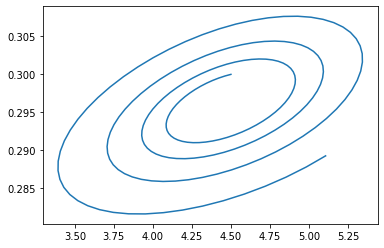

In [6]:
dt = 0.3
x0 = np.array([[4.5, 0.3]])
tra_v = []
tra_w = []
tra_v.append(x0[:, 0])
tra_w.append(x0[:, 1])
data = x0
for i in range(200):
    v = fun_vt(data, dt)
    w = fun_wt(data, dt)
    data = np.concatenate([v.reshape(-1,1), w.reshape(-1,1)], axis=1)
    tra_v.append(v)
    tra_w.append(w)

plt.plot(np.array(tra_v), np.array(tra_w))

In [7]:
unstable_x, unstable_y = np.array(tra_v).mean(), np.array(tra_w).mean()
unstable_x, unstable_y

(4.396212523538953, 0.2951803889988319)

In [8]:
steady = np.load('homocline_point.npy')
cycle = np.load('homocline_cycle.npy')

In [9]:
plt.rcParams['font.family'] = 'Arial'

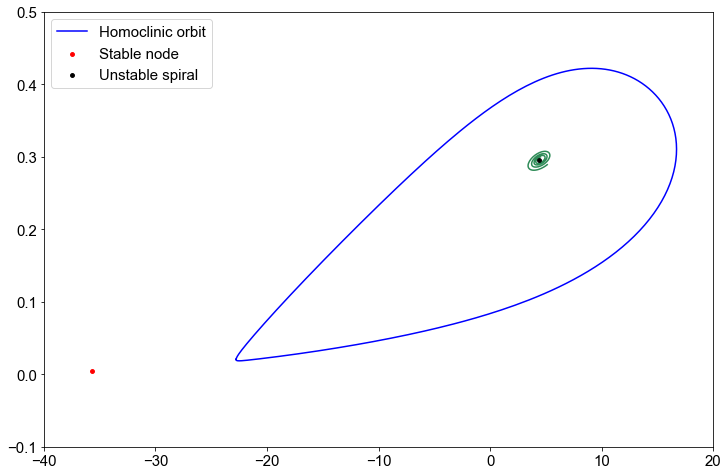

In [10]:
plt.figure(figsize=(12,8))
plt.plot(cycle[:,0], cycle[:,1], c='b', label='Homoclinic orbit')
plt.scatter(steady[0], steady[1], c='r', s=15, label='Stable node')
plt.scatter(unstable_x, unstable_y, c='black',zorder=2, s=15, label='Unstable spiral')
plt.plot(np.array(tra_v), np.array(tra_w),zorder=1, c='seagreen')
plt.xlim(-40,20)
plt.ylim(-0.1,0.5)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=15, loc='upper left')
# plt.savefig('morris_homoclinic.png', bbox_inches='tight', dpi=150)
plt.show()